# 5. Core Pooled Hypothesis Tests (H1–H4) + RQ1–RQ3
## Party ID (categorical) with Ideology Control — Mixed-Effects Models

**Design decisions:**
1. Party as categorical (`party_3`: Democrat/Independent/Republican, Democrat = reference)
2. Ideology as covariate control (not a parallel separate model)
3. `C(theme)` included ONLY when DV is NOT within-theme z-scored
4. Attention filter: `passes_attention == 1`
5. Continuous `party_centered` as robustness check

**What each hypothesis tests and what coefficient matters:**

| H   | Question | Key coefficient |
|-----|----------|-----------------|
| H1A | Do base-rate beliefs predict preferences? | `fpr_aligned`, `fnr_aligned` |
| H1B | Do error thresholds predict preferences? | `log_ratio_aligned` |
| H2  | Does priming change the party gap in thresholds? | `Republican : B_before_T` interaction |
| H3  | Is the party gap larger for preferences than thresholds? | `Republican : is_preference` interaction |
| H4  | Does articulation shrink the party gap in preferences? | `Republican : BT_before_P` interaction |

## Setup & Data Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/My Drive/Projects/SDT/Data/cleaned_data.csv'
SAVE_DIR = '/content/drive/My Drive/Projects/SDT/Data/descriptive/'

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import norm, ttest_rel, wilcoxon
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Loaded: 670 rows × 541 columns


## Data Transformation

In [ ]:
"""
Data Transformation Block
=========================
Derives all variables needed for pooled hypothesis testing.
"""

THEMES = ['disease', 'armed', 'conv', 'welfare', 'immi',
          'vote', 'air', 'firearm', 'auto']

THEME_NAMES = {
    'disease': 'Disease Testing',    'armed': 'Armed Conflict',
    'conv': 'Criminal Justice',      'welfare': 'Welfare',
    'immi': 'Immigration',           'vote': 'Voting/ID',
    'air': 'Airport Security',       'firearm': 'Firearms',
    'auto': 'Autonomous Driving',
}

THEME_PREF_MAP = {
    'armed': 'hawk_scale',       'conv': 'pref_crime_rec',
    'welfare': 'pref_work_rec',  'immi': 'pref_imm_rec',
    'vote': 'pref_id_rec',      'air': 'civlib_scale',
    'firearm': 'pref_guns_rec',
}
# disease and auto have no matched preference → excluded from H1/H3/H4

THEME_VALENCE = {
    'disease': 'neutral',   'armed': 'conservative', 'conv': 'conservative',
    'welfare': 'liberal',   'immi': 'conservative',  'vote': 'conservative',
    'air': 'neutral',       'firearm': 'liberal',    'auto': 'neutral',
}

FPR_ALIGN = {t: (-1 if v == 'liberal' else 1) for t, v in THEME_VALENCE.items()}

# --- Derive wide-format variables ---
df['party_3'] = pd.cut(
    df['party_id_7'], bins=[0, 3, 4, 7],
    labels=['Democrat', 'Independent', 'Republican']
)
df['party_binary'] = np.where(
    df['party_id_7'] <= 3, 'Democrat',
    np.where(df['party_id_7'] >= 5, 'Republican', 'Independent')
)
df['party_centered'] = df['party_id_7'] - df['party_id_7'].mean()
df['ideology_centered'] = df['ideology_num'] - df['ideology_num'].mean()

for theme in THEMES:
    tpr_col = f'{theme}_tpr'
    fnr_col = f'{theme}_fnr'
    if tpr_col in df.columns and fnr_col not in df.columns:
        df[fnr_col] = 1.0 - df[tpr_col]

def get_mask(df):
    return df['passes_attention'] == 1

mask = get_mask(df)
print(f"Attentive: {mask.sum()} / {len(df)}")

Attentive: 649 / 670


## Long-Format Data Builder

In [ ]:
"""
Builds the respondent × theme long-format dataset.
One row per participant per assigned theme.
"""

def build_long(df, use_attentive=True):
    if use_attentive:
        df = df[get_mask(df)].copy()

    rows = []
    for idx, row in df.iterrows():
        resp_id = row.get('ResponseId', idx)
        for theme in THEMES:
            pref_var = THEME_PREF_MAP.get(theme)
            fpr = row.get(f'{theme}_fpr')
            tpr = row.get(f'{theme}_tpr')

            r = {
                'respondent_id': resp_id,
                'theme': theme,
                'theme_name': THEME_NAMES[theme],
                'fpr': fpr,
                'tpr': tpr,
                'fnr': row.get(f'{theme}_fnr'),
                'd_prime': row.get(f'{theme}_d_prime'),
                'c_sdt': row.get(f'{theme}_c'),
                'log_ratio': row.get(f'{theme}_err_log_ratio'),
                'log_ratio_aligned': row.get(f'{theme}_err_log_ratio_aligned'),
                'preference': row.get(pref_var) if pref_var else np.nan,
                'party_id_7': row.get('party_id_7'),
                'party_3': row.get('party_3'),
                'party_centered': row.get('party_centered'),
                'ideology_num': row.get('ideology_num'),
                'ideology_centered': row.get('ideology_centered'),
                'B_before_T': row.get('B_before_T'),
                'BT_before_P': row.get('BT_before_P'),
                'num_correct': row.get('num_correct'),
                'pknow_score': row.get('pknow_score'),
                'risk_taking_mean': row.get('risk_taking_mean'),
                'risk_crra_estimate': row.get('risk_crra_estimate'),
                'age': row.get('age'),
                'education_num': row.get('education_num'),
                'income_num': row.get('income_num'),
                'gender_clean': row.get('gender_clean'),
            }
            sign = FPR_ALIGN.get(theme, 1)
            r['fpr_aligned'] = r['fpr'] * sign if pd.notna(r['fpr']) else np.nan
            r['fnr_aligned'] = r['fnr'] * sign if pd.notna(r['fnr']) else np.nan
            rows.append(r)

    long = pd.DataFrame(rows)

    # party_3 as proper categorical with Democrat as reference
    long['party_3'] = pd.Categorical(
        long['party_3'],
        categories=['Democrat', 'Independent', 'Republican'],
        ordered=False
    )

    # Z-score preference within theme
    long['preference_z'] = long.groupby('theme')['preference'].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
    )

    # Demographic controls
    long['male'] = (long['gender_clean'] == 'Male').astype(float)
    long.loc[~long['gender_clean'].isin(['Male', 'Female']), 'male'] = np.nan

    # Standardize continuous variables
    for m in ['age', 'education_num', 'income_num', 'ideology_centered',
              'd_prime', 'c_sdt', 'fpr_aligned', 'fnr_aligned', 'log_ratio_aligned',
              'num_correct', 'pknow_score', 'risk_taking_mean', 'risk_crra_estimate']:
        if m in long.columns:
            mu, sd = long[m].mean(), long[m].std()
            long[f'{m}_z'] = (long[m] - mu) / sd if sd > 0 else 0

    return long

long = build_long(df, use_attentive=True)
n_resp = long['respondent_id'].nunique()
print(f"Long-format: {len(long)} obs from {n_resp} participants "
      f"× {long['theme'].nunique()} themes")
print(f"  with preference:     {long['preference'].notna().sum()}")
print(f"  with log_ratio:      {long['log_ratio'].notna().sum()}")
print(f"  with fpr:            {long['fpr'].notna().sum()}")
print(f"  with d_prime:        {long['d_prime'].notna().sum()}")

Long-format: 5841 obs from 649 participants × 9 themes
  with preference:     4543
  with log_ratio:      3325
  with fpr:            4447
  with d_prime:        4363


## Model Utilities

### Control variable tiers:
- **Tier 1**: No controls (raw relationship)
- **Tier 2**: Demographics + Ideology (`age_z + education_num_z + income_num_z + male + ideology_centered_z`)
- **Tier 3**: Tier 2 + SDT beliefs (`d_prime_z + c_sdt_z`) — only when DV is NOT a base-rate measure

### C(theme) rule:
- **Include** when DV is NOT within-theme z-scored (`log_ratio`, `d_prime`, `c_sdt`)
- **Omit** when DV IS within-theme z-scored (`preference_z`, `dv_z`)

In [ ]:
# =========================================================================
# CONSTANTS
# =========================================================================

DEMO_CONTROLS = 'age_z + education_num_z + income_num_z + male'
IDEO_CONTROL = 'ideology_centered_z'
BASE_CONTROLS = 'd_prime_z + c_sdt_z'
DEMO_IDEO = DEMO_CONTROLS + ' + ' + IDEO_CONTROL
FULL_CONTROLS = DEMO_IDEO + ' + ' + BASE_CONTROLS

# Shorthand for the party categorical term
PARTY_CAT = "C(party_3, Treatment('Democrat'))"

# Coefficient name prefixes that statsmodels generates:
#   Main:        C(party_3, Treatment('Democrat'))[T.Republican]
#   Interaction: C(party_3, Treatment('Democrat'))[T.Republican]:B_before_T
REP_MAIN = "C(party_3, Treatment('Democrat'))[T.Republican]"
IND_MAIN = "C(party_3, Treatment('Democrat'))[T.Independent]"


# =========================================================================
# MODEL FITTING
# =========================================================================

def run_mixed(formula, data, groups='respondent_id', label=''):
    """
    Fit mixed-effects model with (1|respondent_id).
    Falls back to OLS if mixed model fails.
    """
    # Parse DV and rough RHS terms for dropna
    dv = formula.split('~')[0].strip()
    rhs = formula.split('~')[1]
    # Extract column names (rough but functional)
    rhs_clean = rhs.replace("C(party_3, Treatment('Democrat'))", 'party_3')
    rhs_clean = rhs_clean.replace('C(theme)', 'theme')
    terms = rhs_clean.replace('*', ' ').replace('+', ' ').replace(':', ' ')
    cols_needed = [c.strip() for c in terms.split()
                   if c.strip() and c.strip() not in ['1', 'Treatment']]
    cols_needed.append(dv)
    cols_needed = [c for c in cols_needed if c in data.columns]

    data_clean = data.dropna(subset=cols_needed)
    result = {'label': label, 'n': len(data_clean),
              'n_participants': data_clean['respondent_id'].nunique() if 'respondent_id' in data_clean.columns else '?',
              'formula': formula}

    if len(data_clean) < 20:
        result['error'] = f'Insufficient data (n={len(data_clean)})'
        return result

    # Try mixed-effects
    try:
        model = smf.mixedlm(formula, data_clean, groups=data_clean[groups])
        fit = model.fit(reml=True, method='powell')
        result['type'] = 'MixedLM'
        result['params'] = fit.fe_params.to_dict()
        result['pvalues'] = fit.pvalues.to_dict()
        result['bse'] = fit.bse.to_dict()
        result['converged'] = fit.converged
        result['llf'] = fit.llf
        re_var = fit.cov_re
        result['re_var'] = (float(re_var.iloc[0, 0]) if hasattr(re_var, 'iloc')
                            else float(re_var))
        result['model'] = fit
        return result
    except Exception:
        pass

    # Fallback: OLS
    try:
        model = smf.ols(formula, data_clean).fit()
        result['type'] = 'OLS (fallback)'
        result['params'] = model.params.to_dict()
        result['pvalues'] = model.pvalues.to_dict()
        result['bse'] = model.bse.to_dict()
        result['r2'] = model.rsquared
        result['model'] = model
    except Exception as e:
        result['error'] = str(e)

    return result


def print_model(res, key_terms=None):
    """Pretty-print model results, highlighting key terms."""
    print(f"\n{'─' * 75}")
    print(f"  {res.get('label', '')}")
    print(f"  {res.get('type', '?')} | n = {res.get('n', '?')} obs "
          f"({res.get('n_participants', '?')} participants)")
    print(f"  {res.get('formula', '')}")
    print(f"{'─' * 75}")
    if 'error' in res:
        print(f"  ERROR: {res['error']}")
        return
    params = res.get('params', {})
    pvals = res.get('pvalues', {})
    bse = res.get('bse', {})
    for k in params:
        p = pvals.get(k, np.nan)
        se = bse.get(k, np.nan)
        sig = ('***' if p < .001 else '**' if p < .01
               else '*' if p < .05 else '†' if p < .1 else '')
        highlight = ''
        if key_terms:
            if any(t in k for t in key_terms):
                highlight = ' ◄'
        print(f"  {k:<58} β={params[k]:>8.4f}  "
              f"SE={se:>7.4f}  p={p:>7.4f} {sig}{highlight}")
    if 're_var' in res:
        print(f"  Random effect var (respondent): {res['re_var']:.4f}")


# =========================================================================
# COEFFICIENT EXTRACTION
# =========================================================================

def find_coef(res, pattern):
    """
    Find a coefficient in model results by regex pattern.
    Returns (beta, p, coef_name) or (NaN, NaN, None).
    """
    params = res.get('params', {})
    pvals = res.get('pvalues', {})
    for k in params:
        if re.search(pattern, k):
            return params[k], pvals.get(k, np.nan), k
    return np.nan, np.nan, None


def find_interaction(res, party_pattern='Republican', iv_name=''):
    """
    Find the interaction term between Republican and a given IV.
    Looks for coefficient names containing BOTH 'Republican' AND iv_name.
    """
    params = res.get('params', {})
    pvals = res.get('pvalues', {})
    for k in params:
        if 'Republican' in k and iv_name in k and ':' in k:
            return params[k], pvals.get(k, np.nan), k
    return np.nan, np.nan, None


# =========================================================================
# TIERED MODEL RUNNER
# =========================================================================

def run_tiered(formula_base, data, label_prefix, key_terms=None,
               include_base_tier=True, include_theme_fe=False):
    """
    Run model across control tiers.

    Parameters:
        formula_base: Formula WITHOUT controls or C(theme).
        include_theme_fe: Add C(theme)? True when DV is NOT z-scored within theme.
        include_base_tier: Add Tier 3 (d_prime_z + c_sdt_z)?
    """
    results = {}
    theme_term = ' + C(theme)' if include_theme_fe else ''

    # Tier 1: No controls
    f1 = formula_base + theme_term
    print(f"\n▸ Tier 1: No controls")
    r1 = run_mixed(f1, data, label=f'{label_prefix} [Tier 1]')
    print_model(r1, key_terms)
    results['tier1'] = r1

    # Tier 2: + Demographics + Ideology
    f2 = formula_base + theme_term + ' + ' + DEMO_IDEO
    print(f"\n▸ Tier 2: + Demographics + Ideology")
    r2 = run_mixed(f2, data, label=f'{label_prefix} [Tier 2: demo+ideo]')
    print_model(r2, key_terms)
    results['tier2'] = r2

    # Tier 3: + Base-rate beliefs
    if include_base_tier:
        f3 = formula_base + theme_term + ' + ' + FULL_CONTROLS
        print(f"\n▸ Tier 3: + Demographics + Ideology + SDT beliefs")
        r3 = run_mixed(f3, data, label=f'{label_prefix} [Tier 3: full]')
        print_model(r3, key_terms)
        results['tier3'] = r3

    return results


def run_robustness_continuous(formula_continuous, data, label):
    """Continuous party_centered version for supplement."""
    print(f"\n  ▸ Robustness: continuous party_centered")
    r = run_mixed(formula_continuous, data,
                  label=f'{label} [continuous robustness]')
    print_model(r, ['party_centered'])
    return r

## H1A: Base-Rate Beliefs → Policy Preferences

**Question**: Do participants' perceived FPR and FNR predict their
policy preferences?

**Key coefficients**: `fpr_aligned` and `fnr_aligned` (the IVs).
Party enters as a **control**, not the focal predictor.

**No `C(theme)`** because DV = `preference_z` is within-theme z-scored.
**No Tier 3** because FPR/FNR ARE the base-rate beliefs.

In [ ]:
print("=" * 70)
print("H1A: BASE-RATE BELIEFS → POLICY PREFERENCES")
print("=" * 70)
print("Key coefficient: fpr_aligned, fnr_aligned (do beliefs predict preferences?)")

h1a_data = long.dropna(subset=['preference_z']).copy()

h1a_results = run_tiered(
    f"preference_z ~ fpr_aligned + fnr_aligned + {PARTY_CAT}",
    h1a_data,
    'H1A: FPR + FNR → Preference',
    key_terms=['fpr_aligned', 'fnr_aligned'],
    include_base_tier=False,   # FPR/FNR ARE the IVs, not controls
    include_theme_fe=False,    # DV is within-theme z-scored
)

H1A: BASE-RATE BELIEFS → POLICY PREFERENCES
Key coefficient: fpr_aligned, fnr_aligned (do beliefs predict preferences?)

▸ Tier 1: No controls

───────────────────────────────────────────────────────────────────────────
  H1A: FPR + FNR → Preference [Tier 1]
  MixedLM | n = 4363 obs (643 participants)
  preference_z ~ fpr_aligned + fnr_aligned + C(party_3, Treatment('Democrat'))
───────────────────────────────────────────────────────────────────────────
  Intercept                                                  β= -0.2305  SE= 0.0246  p= 0.0000 ***
  C(party_3, Treatment('Democrat'))[T.Independent]           β=  0.3019  SE= 0.0554  p= 0.0000 ***
  C(party_3, Treatment('Democrat'))[T.Republican]            β=  0.5857  SE= 0.0382  p= 0.0000 ***
  fpr_aligned                                                β= -0.1751  SE= 0.0477  p= 0.0002 *** ◄
  fnr_aligned                                                β=  0.1193  SE= 0.0376  p= 0.0015 ** ◄
  Random effect var (respondent): 0.1056

▸ 

In [ ]:
# H1A Moderated: does the belief→preference link differ by party?
print("\n" + "=" * 70)
print("H1A (MODERATED): Party × Base-Rate Interaction")
print("=" * 70)
print("Key coefficient: Republican × fpr_aligned interaction")
print("(Does the belief→preference link differ for R vs D?)")

h1a_mod_results = run_tiered(
    f"preference_z ~ fpr_aligned * {PARTY_CAT} + fnr_aligned * {PARTY_CAT}",
    h1a_data,
    'H1A moderated',
    key_terms=['fpr_aligned', 'fnr_aligned', 'Republican', ':'],
    include_base_tier=False,
    include_theme_fe=False,
)

# Robustness: continuous
run_robustness_continuous(
    'preference_z ~ fpr_aligned * party_centered + fnr_aligned * party_centered',
    h1a_data, 'H1A')


H1A (MODERATED): Party × Base-Rate Interaction
Key coefficient: Republican × fpr_aligned interaction
(Does the belief→preference link differ for R vs D?)

▸ Tier 1: No controls

───────────────────────────────────────────────────────────────────────────
  H1A moderated [Tier 1]
  MixedLM | n = 4363 obs (643 participants)
  preference_z ~ fpr_aligned * C(party_3, Treatment('Democrat')) + fnr_aligned * C(party_3, Treatment('Democrat'))
───────────────────────────────────────────────────────────────────────────
  Intercept                                                  β= -0.2436  SE= 0.0251  p= 0.0000 ***
  C(party_3, Treatment('Democrat'))[T.Independent]           β=  0.3455  SE= 0.0572  p= 0.0000 ***
  C(party_3, Treatment('Democrat'))[T.Republican]            β=  0.6042  SE= 0.0398  p= 0.0000 *** ◄
  fpr_aligned                                                β= -0.0946  SE= 0.0667  p= 0.1563  ◄
  fpr_aligned:C(party_3, Treatment('Democrat'))[T.Independent] β= -0.2506  SE= 0.1511  p

{'label': 'H1A [continuous robustness]',
 'n': 4363,
 'n_participants': 643,
 'formula': 'preference_z ~ fpr_aligned * party_centered + fnr_aligned * party_centered',
 'type': 'MixedLM',
 'params': {'Intercept': 0.016178316772584043,
  'fpr_aligned': -0.174698903646683,
  'party_centered': 0.12482512488902105,
  'fpr_aligned:party_centered': -0.030403834149194488,
  'fnr_aligned': 0.12235849790870736,
  'fnr_aligned:party_centered': -0.007991290341973045},
 'pvalues': {'Intercept': 0.37836250344964995,
  'fpr_aligned': 0.0002528537413382095,
  'party_centered': 1.4757917436688594e-49,
  'fpr_aligned:party_centered': 0.1583802994835144,
  'fnr_aligned': 0.0011487250824641336,
  'fnr_aligned:party_centered': 0.6445905004979913,
  'Group Var': 2.2471621420490155e-19},
 'bse': {'Intercept': 0.018365304064767534,
  'fpr_aligned': 0.04774039218846735,
  'party_centered': 0.008434415951355377,
  'fpr_aligned:party_centered': 0.021554748215953455,
  'fnr_aligned': 0.037633541493349576,
  'fnr_

## H1B: Error Thresholds → Policy Preferences

**Question**: Do participants' stated error thresholds predict
their policy preferences?

**Key coefficient**: `log_ratio_aligned` (the IV).

**Tier 3 included**: Tests whether thresholds predict preferences
above and beyond base-rate beliefs (d' and c).

**No `C(theme)`**: DV = `preference_z` is within-theme z-scored.

In [ ]:
print("=" * 70)
print("H1B: ERROR THRESHOLDS → POLICY PREFERENCES")
print("=" * 70)
print("Key coefficient: log_ratio_aligned (do thresholds predict preferences?)")

h1b_data = long.dropna(subset=['preference_z', 'log_ratio_aligned']).copy()

h1b_results = run_tiered(
    f"preference_z ~ log_ratio_aligned + {PARTY_CAT}",
    h1b_data,
    'H1B: logR_aligned → Preference',
    key_terms=['log_ratio_aligned'],
    include_base_tier=True,    # Does threshold predict ABOVE base-rate beliefs?
    include_theme_fe=False,    # DV is within-theme z-scored
)

# Robustness: continuous
run_robustness_continuous(
    'preference_z ~ log_ratio_aligned + party_centered',
    h1b_data, 'H1B')

H1B: ERROR THRESHOLDS → POLICY PREFERENCES
Key coefficient: log_ratio_aligned (do thresholds predict preferences?)

▸ Tier 1: No controls

───────────────────────────────────────────────────────────────────────────
  H1B: logR_aligned → Preference [Tier 1]
  MixedLM | n = 2347 obs (616 participants)
  preference_z ~ log_ratio_aligned + C(party_3, Treatment('Democrat'))
───────────────────────────────────────────────────────────────────────────
  Intercept                                                  β= -0.2331  SE= 0.0317  p= 0.0000 ***
  C(party_3, Treatment('Democrat'))[T.Independent]           β=  0.3948  SE= 0.0717  p= 0.0000 ***
  C(party_3, Treatment('Democrat'))[T.Republican]            β=  0.7069  SE= 0.0489  p= 0.0000 ***
  log_ratio_aligned                                          β=  0.0427  SE= 0.0161  p= 0.0080 ** ◄
  Random effect var (respondent): 0.1147

▸ Tier 2: + Demographics + Ideology

───────────────────────────────────────────────────────────────────────────


{'label': 'H1B [continuous robustness]',
 'n': 2347,
 'n_participants': 616,
 'formula': 'preference_z ~ log_ratio_aligned + party_centered',
 'type': 'MixedLM',
 'params': {'Intercept': 0.06892229652499704,
  'log_ratio_aligned': 0.043518201091210955,
  'party_centered': 0.1447613369717458},
 'pvalues': {'Intercept': 0.0027135609711998743,
  'log_ratio_aligned': 0.0070456133445504065,
  'party_centered': 1.8603254326219866e-43,
  'Group Var': 2.9912743430172063e-09},
 'bse': {'Intercept': 0.022985969928205497,
  'log_ratio_aligned': 0.01614966951130769,
  'party_centered': 0.010472745834132153,
  'Group Var': 0.028602477218597256},
 'converged': True,
 'llf': np.float64(-3100.9660637837205),
 're_var': 0.12186697521781091,
 'model': <statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper at 0x79b18c4fb770>}

## H2: Base-Rate Priming Increases Partisan Polarization in Thresholds

**Question**: Does seeing base-rate questions before threshold questions
increase the party gap in error thresholds?

**Key coefficient**: `Republican : B_before_T` **interaction**.
A significant positive interaction means Republicans shift thresholds
more (in the conservative direction) when primed with base rates.

**`C(theme)` included**: DV = raw `log_ratio` is NOT z-scored within theme.

In [ ]:
print("=" * 70)
print("H2: BASE-RATE PRIMING → THRESHOLD POLARIZATION")
print("=" * 70)
print("Key coefficient: Republican × B_before_T INTERACTION")
print("(Does priming change the party gap in thresholds?)")

h2_data = long.dropna(subset=['log_ratio', 'B_before_T']).copy()

h2_results = run_tiered(
    f"log_ratio ~ {PARTY_CAT} * B_before_T",
    h2_data,
    'H2: Order × Party → Threshold',
    key_terms=['Republican', 'B_before_T', ':'],
    include_base_tier=True,    # Does priming effect survive beyond belief changes?
    include_theme_fe=True,     # DV is raw log_ratio
)

# Robustness: continuous
run_robustness_continuous(
    'log_ratio ~ party_centered * B_before_T + C(theme)',
    h2_data, 'H2')

H2: BASE-RATE PRIMING → THRESHOLD POLARIZATION
Key coefficient: Republican × B_before_T INTERACTION
(Does priming change the party gap in thresholds?)

▸ Tier 1: No controls

───────────────────────────────────────────────────────────────────────────
  H2: Order × Party → Threshold [Tier 1]
  MixedLM | n = 3325 obs (630 participants)
  log_ratio ~ C(party_3, Treatment('Democrat')) * B_before_T + C(theme)
───────────────────────────────────────────────────────────────────────────
  Intercept                                                  β=  0.8612  SE= 0.0701  p= 0.0000 ***
  C(party_3, Treatment('Democrat'))[T.Independent]           β= -0.0632  SE= 0.1087  p= 0.5608 
  C(party_3, Treatment('Democrat'))[T.Republican]            β=  0.1141  SE= 0.0615  p= 0.0638 † ◄
  C(theme)[T.armed]                                          β= -1.4982  SE= 0.0827  p= 0.0000 ***
  C(theme)[T.auto]                                           β= -0.1085  SE= 0.0843  p= 0.1978 
  C(theme)[T.conv]         

{'label': 'H2 [continuous robustness]',
 'n': 3325,
 'n_participants': 630,
 'formula': 'log_ratio ~ party_centered * B_before_T + C(theme)',
 'type': 'MixedLM',
 'params': {'Intercept': 0.9002362187198474,
  'C(theme)[T.armed]': -1.4991364886786729,
  'C(theme)[T.auto]': -0.10873086334126879,
  'C(theme)[T.conv]': -1.3366993700077097,
  'C(theme)[T.disease]': -0.17739109167029662,
  'C(theme)[T.firearm]': -0.27566702388298053,
  'C(theme)[T.immi]': -0.828194845601554,
  'C(theme)[T.vote]': -0.9536910148709933,
  'C(theme)[T.welfare]': -1.375142274760118,
  'party_centered': 0.02032862760329673,
  'B_before_T': -0.026222920068560963,
  'party_centered:B_before_T': 0.009425440286851801},
 'pvalues': {'Intercept': 2.62671028332862e-44,
  'C(theme)[T.armed]': 1.777893416477683e-73,
  'C(theme)[T.auto]': 0.19691871269216943,
  'C(theme)[T.conv]': 1.8896865218332303e-63,
  'C(theme)[T.disease]': 0.03129845512045667,
  'C(theme)[T.firearm]': 0.0006902780092641333,
  'C(theme)[T.immi]': 5.147

## H3: Preference Polarization > Threshold Polarization

**Question**: Is the party gap larger for policy preferences than for
error thresholds? This tests the paper's core argument: conventional
preference measures inflate apparent polarization relative to the
more precise threshold measure.

**Method**: Stacked interaction approach. Concatenate `preference_z` and
`threshold_z` (within-theme z-scored log_ratio_aligned) into a single DV,
with `is_preference` indicator. The interaction `Republican × is_preference`
tests whether the party effect is larger for preferences.

**Key coefficient**: `Republican : is_preference` **interaction**.
A positive interaction means preferences are MORE polarized than thresholds.

**No `C(theme)`**: Both components of the stacked DV are z-scored within theme.

In [ ]:
print("=" * 70)
print("H3: RELATIVE POLARIZATION — PREFERENCES vs THRESHOLDS")
print("=" * 70)
print("Key coefficient: Republican × is_preference INTERACTION")
print("(Is the party gap larger for preferences than thresholds?)")

# Restrict to themes with BOTH preference and threshold data
h3_themes = list(THEME_PREF_MAP.keys())
h3_base = long[long['theme'].isin(h3_themes)].copy()

# Stack 1: preference_z rows
pref_rows = h3_base.dropna(subset=['preference_z']).copy()
pref_rows['dv_z'] = pref_rows['preference_z']
pref_rows['is_preference'] = 1

# Stack 2: log_ratio_aligned, z-scored within theme for comparability
thresh_rows = h3_base.dropna(subset=['log_ratio_aligned']).copy()
thresh_rows['dv_z'] = thresh_rows.groupby('theme')['log_ratio_aligned'].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
)
thresh_rows['is_preference'] = 0

h3_stacked = pd.concat([pref_rows, thresh_rows], ignore_index=True)

# Re-set party_3 as categorical (lost during concat)
h3_stacked['party_3'] = pd.Categorical(
    h3_stacked['party_3'],
    categories=['Democrat', 'Independent', 'Republican'],
    ordered=False
)

print(f"H3 stacked data: {len(h3_stacked)} obs "
      f"({len(pref_rows)} preference + {len(thresh_rows)} threshold)")
print(f"  from {h3_stacked['respondent_id'].nunique()} participants")

h3_results = run_tiered(
    f"dv_z ~ {PARTY_CAT} * is_preference",
    h3_stacked,
    'H3: Party × Measure Type',
    key_terms=['Republican', 'is_preference', ':'],
    include_base_tier=False,   # DV is z-scored, base-rate controls don't apply cleanly
    include_theme_fe=False,    # DV is z-scored within theme
)

# --- Descriptive: theme-by-theme D–R gaps ---
print(f"\n{'─' * 70}")
print(f"  Descriptive: D–R gaps per theme (raw means)")
print(f"{'─' * 70}")
print(f"  {'Theme':<20} {'|Δ_pref(D-R)|':>16} {'|Δ_thresh(D-R)|':>18}")
print(f"  {'─' * 56}")

for theme in h3_themes:
    td = h3_base[h3_base['theme'] == theme]
    for var, label in [('preference', 'pref'), ('log_ratio_aligned', 'thresh')]:
        dem = td[td['party_id_7'] <= 3][var].dropna()
        rep = td[td['party_id_7'] >= 5][var].dropna()
        if label == 'pref':
            d_pref = abs(dem.mean() - rep.mean()) if len(dem) > 0 and len(rep) > 0 else np.nan
        else:
            d_thresh = abs(dem.mean() - rep.mean()) if len(dem) > 0 and len(rep) > 0 else np.nan
    print(f"  {THEME_NAMES[theme]:<20} {d_pref:>16.3f} {d_thresh:>18.3f}")

# Robustness: continuous
run_robustness_continuous(
    'dv_z ~ party_centered * is_preference',
    h3_stacked, 'H3')

H3: RELATIVE POLARIZATION — PREFERENCES vs THRESHOLDS
Key coefficient: Republican × is_preference INTERACTION
(Is the party gap larger for preferences than thresholds?)
H3 stacked data: 6890 obs (4543 preference + 2347 threshold)
  from 649 participants

▸ Tier 1: No controls

───────────────────────────────────────────────────────────────────────────
  H3: Party × Measure Type [Tier 1]
  MixedLM | n = 6890 obs (649 participants)
  dv_z ~ C(party_3, Treatment('Democrat')) * is_preference
───────────────────────────────────────────────────────────────────────────
  Intercept                                                  β= -0.0957  SE= 0.0316  p= 0.0025 **
  C(party_3, Treatment('Democrat'))[T.Independent]           β=  0.1160  SE= 0.0723  p= 0.1086 
  C(party_3, Treatment('Democrat'))[T.Republican]            β=  0.1806  SE= 0.0492  p= 0.0002 *** ◄
  is_preference                                              β= -0.2239  SE= 0.0324  p= 0.0000 *** ◄
  C(party_3, Treatment('Democrat'))

{'label': 'H3 [continuous robustness]',
 'n': 6890,
 'n_participants': 649,
 'formula': 'dv_z ~ party_centered * is_preference',
 'type': 'MixedLM',
 'params': {'Intercept': -0.01733825920373953,
  'party_centered': 0.03720777019045194,
  'is_preference': 0.024116201947883394,
  'party_centered:is_preference': 0.12064413080232139},
 'pvalues': {'Intercept': 0.4483482203674781,
  'party_centered': 0.00038518202270524586,
  'is_preference': 0.30003431006888115,
  'party_centered:is_preference': 1.1319607168171762e-29,
  'Group Var': 1.0708453695163153e-21},
 'bse': {'Intercept': 0.022868513760471946,
  'party_centered': 0.010480962898734968,
  'is_preference': 0.023270105211545124,
  'party_centered:is_preference': 0.01066423448676357,
  'Group Var': 0.013390743066787305},
 'converged': True,
 'llf': np.float64(-9370.099443978877),
 're_var': 0.10471791392134164,
 'model': <statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper at 0x79b18bd74530>}

## H4: Threshold Articulation Reduces Preference Polarization

**Question**: Does articulating error thresholds before stating preferences
reduce the party gap in preferences? This tests whether the SDT
decomposition actually changes how people express preferences.

**Key coefficient**: `Republican : BT_before_P` **interaction**.
A negative interaction means the R–D preference gap is **smaller**
when participants articulated thresholds first.

**No `C(theme)`**: DV = `preference_z` is within-theme z-scored.

In [ ]:
print("=" * 70)
print("H4: THRESHOLD ARTICULATION → REDUCED PREFERENCE POLARIZATION")
print("=" * 70)
print("Key coefficient: Republican × BT_before_P INTERACTION")
print("(Does articulating thresholds first shrink the party preference gap?)")

h4_data = long.dropna(subset=['preference_z', 'BT_before_P']).copy()

h4_results = run_tiered(
    f"preference_z ~ {PARTY_CAT} * BT_before_P",
    h4_data,
    'H4: Articulation × Party → Preference',
    key_terms=['Republican', 'BT_before_P', ':'],
    include_base_tier=True,    # Does effect survive beyond belief changes?
    include_theme_fe=False,    # DV is within-theme z-scored
)

# Robustness: continuous
run_robustness_continuous(
    'preference_z ~ party_centered * BT_before_P',
    h4_data, 'H4')

H4: THRESHOLD ARTICULATION → REDUCED PREFERENCE POLARIZATION
Key coefficient: Republican × BT_before_P INTERACTION
(Does articulating thresholds first shrink the party preference gap?)

▸ Tier 1: No controls

───────────────────────────────────────────────────────────────────────────
  H4: Articulation × Party → Preference [Tier 1]
  MixedLM | n = 5841 obs (649 participants)
  preference_z ~ C(party_3, Treatment('Democrat')) * BT_before_P
───────────────────────────────────────────────────────────────────────────
  Intercept                                                  β= -0.2507  SE= 0.0310  p= 0.0000 ***
  C(party_3, Treatment('Democrat'))[T.Independent]           β=  0.3195  SE= 0.0747  p= 0.0000 ***
  C(party_3, Treatment('Democrat'))[T.Republican]            β=  0.6109  SE= 0.0493  p= 0.0000 *** ◄
  BT_before_P                                                β=  0.0044  SE= 0.0447  p= 0.9216  ◄
  C(party_3, Treatment('Democrat'))[T.Independent]:BT_before_P β= -0.0120  SE= 0.103

{'label': 'H4 [continuous robustness]',
 'n': 5841,
 'n_participants': 649,
 'formula': 'preference_z ~ party_centered * BT_before_P',
 'type': 'MixedLM',
 'params': {'Intercept': 0.0017337417221134582,
  'party_centered': 0.12589719208894562,
  'BT_before_P': 0.007094264417511352,
  'party_centered:BT_before_P': -0.006096379893517744},
 'pvalues': {'Intercept': 0.9398903673120726,
  'party_centered': 8.01824938264275e-32,
  'BT_before_P': 0.8290301148267651,
  'party_centered:BT_before_P': 0.6849058917700324,
  'Group Var': 7.290980739540244e-26},
 'bse': {'Intercept': 0.022991587269695572,
  'party_centered': 0.010724454872374362,
  'BT_before_P': 0.03285208337152533,
  'party_centered:BT_before_P': 0.015023937490634721,
  'Group Var': 0.017304867170019094},
 'converged': True,
 'llf': np.float64(-7106.864012699953),
 're_var': 0.10862823285696241,
 'model': <statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper at 0x79b18bd72b40>}

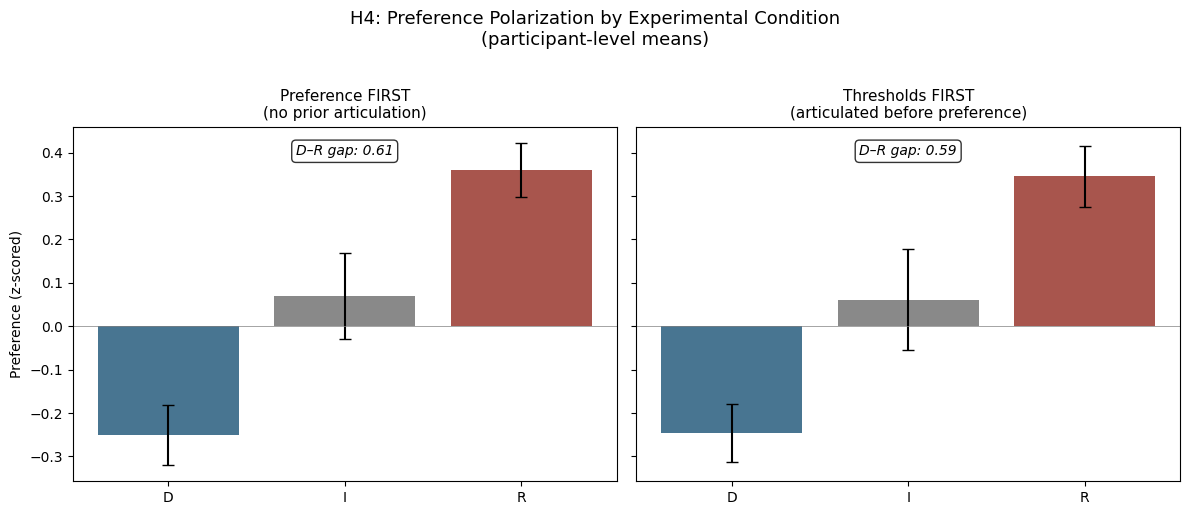

In [ ]:
# --- H4 Split-Sample Visualization ---
# Show party means separately for BT_before_P = 0 vs 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

PARTY_COLORS = {'Democrat': '#1a5276', 'Independent': '#6c6c6c', 'Republican': '#922b21'}
party_order = ['Democrat', 'Independent', 'Republican']

for ax_idx, (cond_val, cond_label) in enumerate(
        [(0, 'Preference FIRST\n(no prior articulation)'),
         (1, 'Thresholds FIRST\n(articulated before preference)')]):
    ax = axes[ax_idx]
    cond_data = h4_data[h4_data['BT_before_P'] == cond_val]

    # Aggregate to participant level FIRST, then get party means
    part_means = (cond_data
                  .groupby(['respondent_id', 'party_3'])['preference_z']
                  .mean()
                  .reset_index())

    party_stats = (part_means
                   .groupby('party_3')['preference_z']
                   .agg(['mean', 'sem'])
                   .reindex(party_order))

    bars = ax.bar(range(3), party_stats['mean'],
                  yerr=party_stats['sem'] * 1.96,
                  color=[PARTY_COLORS[p] for p in party_order],
                  capsize=4, alpha=0.8)

    # D-R gap annotation
    d_mean = party_stats.loc['Democrat', 'mean']
    r_mean = party_stats.loc['Republican', 'mean']
    gap = abs(r_mean - d_mean)
    ax.text(0.5, 0.95, f'D–R gap: {gap:.2f}',
            transform=ax.transAxes, ha='center', va='top',
            fontstyle='italic', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax.set_xticks(range(3))
    ax.set_xticklabels(['D', 'I', 'R'])
    ax.set_title(cond_label, fontsize=11)
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='-')
    if ax_idx == 0:
        ax.set_ylabel('Preference (z-scored)')

fig.suptitle('H4: Preference Polarization by Experimental Condition\n(participant-level means)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Pooled ROC: Where Does Partisan Disagreement Live?

Tests whether parties differ in perceived sensitivity (d') vs
response criterion (c). These are base-rate-derived measures,
so no Tier 3 controls.

**`C(theme)` included**: DV = raw d' and c are NOT z-scored.

In [ ]:
print("=" * 70)
print("POOLED SDT MODELS: d' and c by Party (categorical)")
print("=" * 70)

sdt_data = long.dropna(subset=['d_prime', 'c_sdt']).copy()
print(f"SDT data: {len(sdt_data)} obs from "
      f"{sdt_data['respondent_id'].nunique()} participants")

# --- d' models ---
print("\n" + "─" * 70)
print("  d' (sensitivity)")
print("─" * 70)
dp_results = run_tiered(
    f"d_prime ~ {PARTY_CAT}",
    sdt_data, "d' ~ Party",
    key_terms=['Republican', 'Independent'],
    include_base_tier=False,   # d' IS a base-rate measure
    include_theme_fe=True,     # DV is raw d'
)

# --- c models ---
print("\n" + "─" * 70)
print("  c (criterion)")
print("─" * 70)
c_results = run_tiered(
    f"c_sdt ~ {PARTY_CAT}",
    sdt_data, "c ~ Party",
    key_terms=['Republican', 'Independent'],
    include_base_tier=False,   # c IS a base-rate measure
    include_theme_fe=True,     # DV is raw c
)

# Robustness: continuous
print("\n--- Robustness: continuous party_centered ---")
run_robustness_continuous('d_prime ~ party_centered + C(theme)', sdt_data, "d'")
run_robustness_continuous('c_sdt ~ party_centered + C(theme)', sdt_data, "c")

POOLED SDT MODELS: d' and c by Party (categorical)
SDT data: 4363 obs from 643 participants

──────────────────────────────────────────────────────────────────────
  d' (sensitivity)
──────────────────────────────────────────────────────────────────────

▸ Tier 1: No controls

───────────────────────────────────────────────────────────────────────────
  d' ~ Party [Tier 1]
  MixedLM | n = 4363 obs (643 participants)
  d_prime ~ C(party_3, Treatment('Democrat')) + C(theme)
───────────────────────────────────────────────────────────────────────────
  Intercept                                                  β=  1.7356  SE= 0.0944  p= 0.0000 ***
  C(party_3, Treatment('Democrat'))[T.Independent]           β= -0.0614  SE= 0.1643  p= 0.7087  ◄
  C(party_3, Treatment('Democrat'))[T.Republican]            β= -0.0463  SE= 0.1133  p= 0.6829  ◄
  C(theme)[T.armed]                                          β=  0.5677  SE= 0.0942  p= 0.0000 ***
  C(theme)[T.auto]                                   

{'label': 'c [continuous robustness]',
 'n': 4363,
 'n_participants': 643,
 'formula': 'c_sdt ~ party_centered + C(theme)',
 'type': 'MixedLM',
 'params': {'Intercept': 0.028926985830094294,
  'C(theme)[T.armed]': 0.12760797413038702,
  'C(theme)[T.auto]': 0.09238882508195984,
  'C(theme)[T.conv]': -0.030151534250195462,
  'C(theme)[T.disease]': 0.0593095947000059,
  'C(theme)[T.firearm]': 0.3144786996819798,
  'C(theme)[T.immi]': 0.012716921213074658,
  'C(theme)[T.vote]': 0.25601736931419855,
  'C(theme)[T.welfare]': 0.0900385905378146,
  'party_centered': 0.00913375876895486},
 'pvalues': {'Intercept': 0.34933421411284105,
  'C(theme)[T.armed]': 0.0031057868355512633,
  'C(theme)[T.auto]': 0.031217884994012426,
  'C(theme)[T.conv]': 0.4828944648405087,
  'C(theme)[T.disease]': 0.17428949899601476,
  'C(theme)[T.firearm]': 2.0036145483206246e-13,
  'C(theme)[T.immi]': 0.7667182785653411,
  'C(theme)[T.vote]': 2.9394258783909657e-09,
  'C(theme)[T.welfare]': 0.03373504194800705,
  'pa


Model-Implied SDT Parameters (from Tier 2):
  Democrat: d' = 1.448, c = 0.017
  Republican: d' = 1.532, c = 0.028


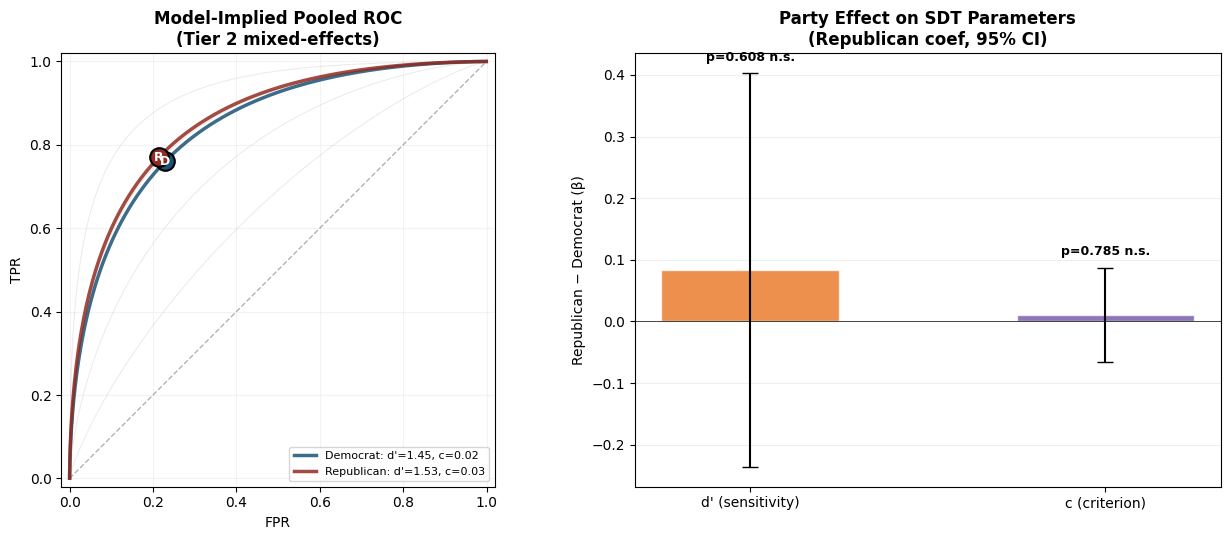


INTERPRETATION
  Partisan disagreement is LARGER in sensitivity (d') than criterion (c).
  → Parties disagree about how well the policy classifies.

  |β_d'| / |β_c| = 7.84


In [ ]:
# --- Pooled ROC Figure ---
from scipy.stats import norm as sp_norm

def roc_curve_from_dprime(d_prime, n_points=200):
    c_range = np.linspace(-4, 4, n_points)
    return sp_norm.cdf(-d_prime/2 - c_range), sp_norm.cdf(d_prime/2 - c_range)

def criterion_to_roc_point(d_prime, c_val):
    return sp_norm.cdf(-d_prime/2 - c_val), sp_norm.cdf(d_prime/2 - c_val)

# Extract model-implied d' and c for each party from Tier 2 models
dp_params = dp_results['tier2'].get('params', {})
c_params = c_results['tier2'].get('params', {})

# Democrat = intercept (reference); Republican = intercept + Republican coef
implied = {}
dp_intercept = dp_params.get('Intercept', np.nan)
c_intercept = c_params.get('Intercept', np.nan)
dp_rep_coef = dp_params.get(REP_MAIN, 0)
c_rep_coef = c_params.get(REP_MAIN, 0)

implied['Democrat'] = {'d_prime': dp_intercept, 'c': c_intercept}
implied['Republican'] = {'d_prime': dp_intercept + dp_rep_coef,
                         'c': c_intercept + c_rep_coef}

print("\nModel-Implied SDT Parameters (from Tier 2):")
for party in ['Democrat', 'Republican']:
    p = implied[party]
    print(f"  {party}: d' = {p['d_prime']:.3f}, c = {p['c']:.3f}")

fig, (ax_roc, ax_bars) = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel A: ROC curves
ax = ax_roc
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
for dp_val in [0.5, 1.0, 1.5, 2.0]:
    fc, tc = roc_curve_from_dprime(dp_val)
    ax.plot(fc, tc, color='gray', alpha=0.15, linewidth=0.8)

for party in ['Democrat', 'Republican']:
    p = implied[party]
    color = PARTY_COLORS[party]
    fc, tc = roc_curve_from_dprime(p['d_prime'])
    ax.plot(fc, tc, color=color, linewidth=2.5, alpha=0.85,
            label=f"{party}: d'={p['d_prime']:.2f}, c={p['c']:.2f}")
    pf, pt = criterion_to_roc_point(p['d_prime'], p['c'])
    ax.scatter(pf, pt, c=color, s=180, marker='o',
               edgecolors='black', linewidth=1.5, zorder=5)
    short = 'D' if party == 'Democrat' else 'R'
    ax.annotate(short, (pf, pt), fontsize=9, fontweight='bold',
                color='white', ha='center', va='center', zorder=6)

ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Model-Implied Pooled ROC\n(Tier 2 mixed-effects)', fontweight='bold')
ax.set_aspect('equal'); ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.15)

# Panel B: Effect sizes (Republican coefficient)
ax = ax_bars
dp_pv = dp_results['tier2'].get('pvalues', {})
dp_se = dp_results['tier2'].get('bse', {})
c_pv = c_results['tier2'].get('pvalues', {})
c_se = c_results['tier2'].get('bse', {})

betas = [dp_rep_coef, c_rep_coef]
errs = [dp_se.get(REP_MAIN, 0) * 1.96, c_se.get(REP_MAIN, 0) * 1.96]
pvals = [dp_pv.get(REP_MAIN, 1), c_pv.get(REP_MAIN, 1)]
colors = ['#e66101', '#5e3c99']
labels = ["d' (sensitivity)", "c (criterion)"]

bars = ax.bar([0, 1], betas, color=colors, alpha=0.7, width=0.5, edgecolor='white')
ax.errorbar([0, 1], betas, yerr=errs, fmt='none', color='black',
            capsize=6, linewidth=1.5)

for i, (b, p) in enumerate(zip(betas, pvals)):
    sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'
    offset = errs[i] + 0.02 if b >= 0 else -(errs[i] + 0.02)
    ax.annotate(f"p={p:.3f} {sig}", (i, b + offset),
                ha='center', fontsize=9, fontweight='bold')

ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Republican − Democrat (β)', fontsize=10)
ax.set_title('Party Effect on SDT Parameters\n(Republican coef, 95% CI)',
             fontweight='bold')
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

# Interpretation
print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
if abs(dp_rep_coef) > abs(c_rep_coef):
    print("  Partisan disagreement is LARGER in sensitivity (d') than criterion (c).")
    print("  → Parties disagree about how well the policy classifies.")
else:
    print("  Partisan disagreement is LARGER in criterion (c) than sensitivity (d').")
    print("  → Parties perceive similar accuracy but disagree about thresholds.")

ratio = abs(dp_rep_coef) / abs(c_rep_coef) if abs(c_rep_coef) > 0.001 else float('inf')
print(f"\n  |β_d'| / |β_c| = {ratio:.2f}")

## RQ1–RQ3: Moderator Analyses

Three-way interactions testing whether numeracy (RQ1), political knowledge
(RQ2), or risk tolerance (RQ3) moderate the party → threshold link.

**`C(theme)` included**: DV = raw `log_ratio`.

In [ ]:
print("=" * 70)
print("RQ1–RQ3: MODERATOR ANALYSES")
print("=" * 70)
print("DV = log_ratio. Key: Republican × moderator interaction.")

rq_data = long.dropna(subset=['log_ratio']).copy()

moderators = [
    ('RQ1: Numeracy', 'num_correct_z'),
    ('RQ2: Political Knowledge', 'pknow_score_z'),
    ('RQ3: Risk Tolerance',
     'risk_taking_mean_z' if 'risk_taking_mean_z' in rq_data.columns
     else 'risk_crra_estimate_z'),
]

rq_results = {}
for rq_label, mod in moderators:
    print(f"\n{'=' * 70}")
    print(f"{rq_label}: {mod}")
    print(f"{'=' * 70}")

    # Categorical party × moderator
    formula = f"log_ratio ~ {PARTY_CAT} * {mod} + C(theme) + {DEMO_IDEO}"
    r = run_mixed(formula, rq_data,
                  label=f'{rq_label} [cat party + controls]')
    print_model(r, ['Republican', mod, ':'])
    rq_results[rq_label] = r

    # Robustness: continuous
    r_cont = run_mixed(
        f'log_ratio ~ party_centered * {mod} + C(theme) + {DEMO_IDEO}',
        rq_data, label=f'{rq_label} [continuous robustness]')
    print_model(r_cont, ['party_centered', mod, ':'])

RQ1–RQ3: MODERATOR ANALYSES
DV = log_ratio. Key: Republican × moderator interaction.

RQ1: Numeracy: num_correct_z

───────────────────────────────────────────────────────────────────────────
  RQ1: Numeracy [cat party + controls]
  MixedLM | n = 3065 obs (576 participants)
  log_ratio ~ C(party_3, Treatment('Democrat')) * num_correct_z + C(theme) + age_z + education_num_z + income_num_z + male + ideology_centered_z
───────────────────────────────────────────────────────────────────────────
  Intercept                                                  β=  0.9118  SE= 0.0710  p= 0.0000 ***
  C(party_3, Treatment('Democrat'))[T.Independent]           β= -0.0277  SE= 0.0705  p= 0.6947 
  C(party_3, Treatment('Democrat'))[T.Republican]            β=  0.0754  SE= 0.0634  p= 0.2344  ◄
  C(theme)[T.armed]                                          β= -1.5255  SE= 0.0860  p= 0.0000 ***
  C(theme)[T.auto]                                           β= -0.0977  SE= 0.0874  p= 0.2637 
  C(theme)[T.con

## Summary Table

Extracts the **correct** coefficient for each hypothesis:
- H1A/H1B: the IV coefficient (do beliefs/thresholds predict preferences?)
- H2/H3/H4: the Republican × condition INTERACTION (does the party gap change?)

In [ ]:
print("=" * 70)
print("SUMMARY OF ALL HYPOTHESIS TESTS")
print("=" * 70)

# Each entry: (test_id, description, results_dict, tier_key,
#              extraction_method, extraction_args)
# extraction_method: 'iv' for IV coefficient, 'interaction' for party × X
summary_specs = [
    ('H1A', 'Base-rate beliefs → Preference',
     h1a_results, 'tier2',
     'iv', 'fpr_aligned',
     'Do base-rate beliefs predict preferences?'),

    ('H1B', 'Error thresholds → Preference',
     h1b_results, 'tier3',
     'iv', 'log_ratio_aligned',
     'Do error thresholds predict preferences (above d\'/c)?'),

    ('H2', 'Priming × Party → Threshold',
     h2_results, 'tier2',
     'interaction', 'B_before_T',
     'Does priming change the R–D gap in thresholds?'),

    ('H3', 'Pref polar. > Thresh polar.',
     h3_results, 'tier2',
     'interaction', 'is_preference',
     'Is the R–D gap larger for preferences than thresholds?'),

    ('H4', 'Articulation reduces polar.',
     h4_results, 'tier2',
     'interaction', 'BT_before_P',
     'Does articulation shrink the R–D preference gap?'),
]

print(f"\n{'Test':<8} {'Description':<35} {'Coefficient':<22} "
      f"{'β':>8} {'SE':>8} {'p':>8} {'n':>6} {'Sig':<4}")
print("─" * 100)

for (test_id, desc, results_dict, tier, method, target, question) in summary_specs:
    res = results_dict.get(tier, {})
    n = res.get('n', '?')

    if method == 'iv':
        # Extract the IV coefficient directly
        b, p, name = find_coef(res, f'^{re.escape(target)}$')
        se_val = res.get('bse', {}).get(target, np.nan)
        coef_label = target
    elif method == 'interaction':
        # Extract the Republican × target interaction
        b, p, name = find_interaction(res, 'Republican', target)
        se_val = res.get('bse', {}).get(name, np.nan) if name else np.nan
        coef_label = f'Rep × {target}'
    else:
        b, p, name, se_val, coef_label = np.nan, np.nan, None, np.nan, '?'

    sig = ('***' if p < .001 else '**' if p < .01
           else '*' if p < .05 else '†' if p < .1 else '')

    print(f"  {test_id:<6} {desc:<35} {coef_label:<22} "
          f"{b:>8.4f} {se_val:>8.4f} {p:>8.4f} {n:>6} {sig:<4}")

print(f"\n{'─' * 100}")
print("Notes:")
print("  H1A, H1B: coefficient is the IV (belief/threshold → preference).")
print("            Party is a CONTROL, not the focal predictor.")
print("  H2–H4:    coefficient is the Republican × condition INTERACTION.")
print("            Tests whether the R–D gap changes across conditions.")
print(f"{'─' * 100}")

SUMMARY OF ALL HYPOTHESIS TESTS

Test     Description                         Coefficient                   β       SE        p      n Sig 
────────────────────────────────────────────────────────────────────────────────────────────────────
  H1A    Base-rate beliefs → Preference      fpr_aligned             -0.1915   0.0496   0.0001   4150 *** 
  H1B    Error thresholds → Preference       log_ratio_aligned        0.0432   0.0167   0.0096   2163 **  
  H2     Priming × Party → Threshold         Rep × B_before_T         0.0247   0.0900   0.7833   3065     
  H3     Pref polar. > Thresh polar.         Rep × is_preference      0.5513   0.0523   0.0000   6314 *** 
  H4     Articulation reduces polar.         Rep × BT_before_P       -0.0978   0.0672   0.1452   5337     

────────────────────────────────────────────────────────────────────────────────────────────────────
Notes:
  H1A, H1B: coefficient is the IV (belief/threshold → preference).
            Party is a CONTROL, not the focal pr

In [ ]:
# --- Detailed interpretation ---
print("\n" + "=" * 70)
print("INTERPRETATION GUIDE")
print("=" * 70)

for (test_id, desc, results_dict, tier, method, target, question) in summary_specs:
    res = results_dict.get(tier, {})
    if method == 'iv':
        b, p, name = find_coef(res, f'^{re.escape(target)}$')
    else:
        b, p, name = find_interaction(res, 'Republican', target)

    sig = p < 0.05 if not np.isnan(p) else False
    print(f"\n  {test_id}: {question}")
    print(f"    β = {b:.4f}, p = {p:.4f} → {'YES' if sig else 'NO'}")

    if test_id == 'H1A' and sig:
        print(f"    Base-rate beliefs significantly predict preferences")
        print(f"    (a 1-unit increase in aligned FPR → {b:.3f} SD change in preference)")
    elif test_id == 'H1B' and sig:
        print(f"    Error thresholds predict preferences above base-rate beliefs")
    elif test_id == 'H2':
        if sig:
            print(f"    Priming significantly changes the R–D threshold gap")
        else:
            print(f"    No evidence that priming changes the R–D threshold gap")
    elif test_id == 'H3':
        if sig and b > 0:
            print(f"    Preferences ARE more polarized than thresholds (H3 supported)")
        elif sig and b < 0:
            print(f"    Thresholds are MORE polarized than preferences (H3 reversed)")
        else:
            print(f"    No significant difference in polarization between measures")
    elif test_id == 'H4':
        if sig and b < 0:
            print(f"    Articulation REDUCES the R–D preference gap (H4 supported)")
        elif sig and b > 0:
            print(f"    Articulation INCREASES the R–D preference gap (H4 reversed)")
        else:
            print(f"    No evidence that articulation changes the preference gap")


INTERPRETATION GUIDE

  H1A: Do base-rate beliefs predict preferences?
    β = -0.1915, p = 0.0001 → YES
    Base-rate beliefs significantly predict preferences
    (a 1-unit increase in aligned FPR → -0.191 SD change in preference)

  H1B: Do error thresholds predict preferences (above d'/c)?
    β = 0.0432, p = 0.0096 → YES
    Error thresholds predict preferences above base-rate beliefs

  H2: Does priming change the R–D gap in thresholds?
    β = 0.0247, p = 0.7833 → NO
    No evidence that priming changes the R–D threshold gap

  H3: Is the R–D gap larger for preferences than thresholds?
    β = 0.5513, p = 0.0000 → YES
    Preferences ARE more polarized than thresholds (H3 supported)

  H4: Does articulation shrink the R–D preference gap?
    β = -0.0978, p = 0.1452 → NO
    No evidence that articulation changes the preference gap
